In [1]:
#Experiment - 5A

print("Welcome to Data Analytics Lab")
print("Experiment 5A")
print("Data Visualization using Matplotlib - Space Mission Data")

Welcome to Data Analytics Lab
Experiment 5A
Data Visualization using Matplotlib - Space Mission Data


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

print("Pandas Version :", pd.__version__)
print("Matplotlib Imported Successfully")

Pandas Version : 3.0.2
Matplotlib Imported Successfully


In [3]:
df = pd.read_csv("all_space_mission_launches.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.head()  #Display First Five Records

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,NaN,Success
1,1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,67.0,Success
2,2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,NaN,Success
3,3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,30.8,Success
4,4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,7.5,Success


In [5]:
df['Datetime'] = pd.to_datetime(df['Datetime'], format='mixed', utc=True, errors='coerce')  #Convert to datetime
df['Year'] = df['Datetime'].dt.year                                                           #Extract Year

print("Data Prepared Successfully!")

Data Prepared Successfully!


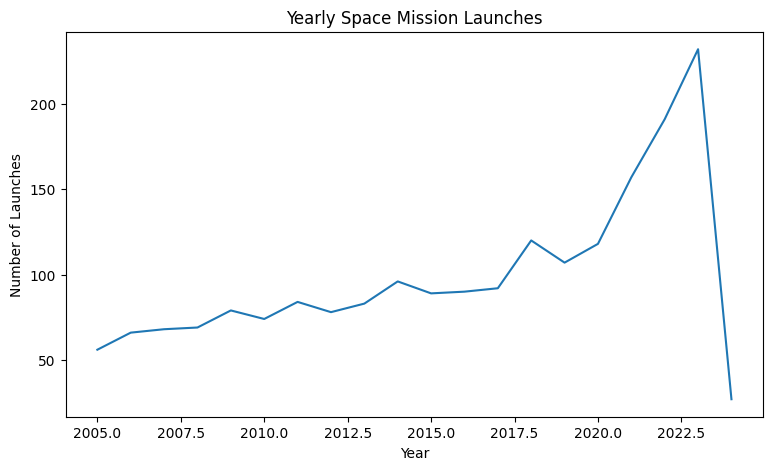

In [6]:
#Algorithm 1: Line Chart - Yearly Space Mission Launches

yearly = df.groupby('Year').size()
yearly_recent = yearly[yearly.index >= 2005]

plt.figure(figsize=(9,5))
plt.plot(yearly_recent.index, yearly_recent.values)

plt.title("Yearly Space Mission Launches")
plt.xlabel("Year")
plt.ylabel("Number of Launches")

plt.show()

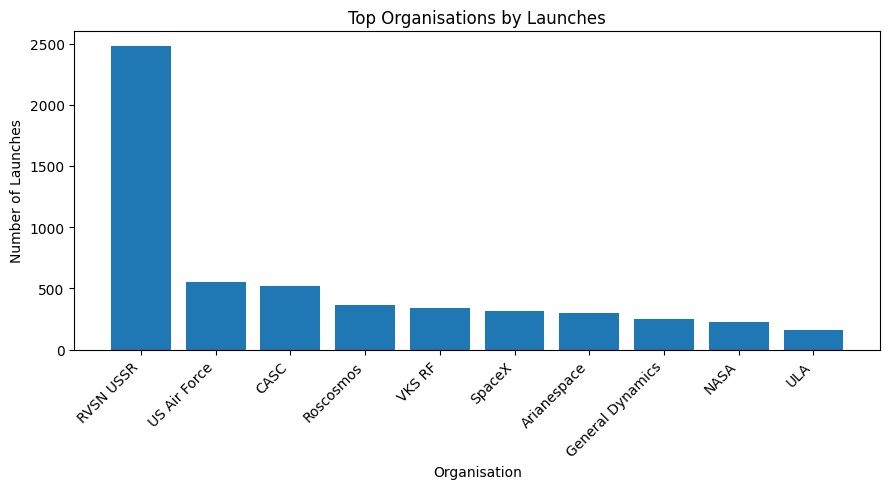

In [7]:
#Algorithm 2: Bar Chart - Top Organisations by Launches

top_orgs = df['Organisation'].value_counts().head(10)

plt.figure(figsize=(9,5))
plt.bar(top_orgs.index, top_orgs.values)

plt.title("Top Organisations by Launches")
plt.xlabel("Organisation")
plt.ylabel("Number of Launches")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

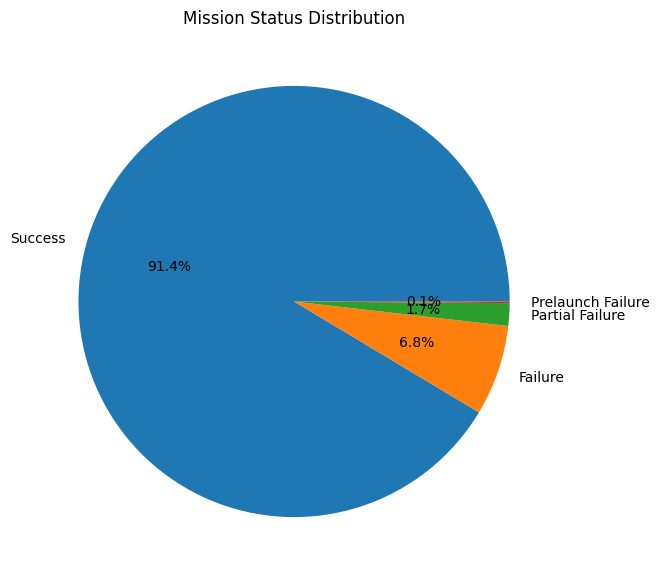

In [8]:
#Algorithm 3: Pie Chart - Mission Status Distribution

status_counts = df['Mission_Status'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')

plt.title("Mission Status Distribution")
plt.show()

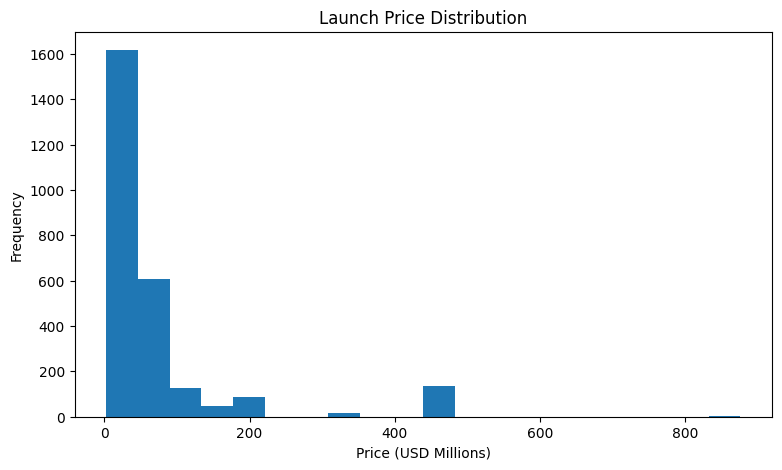

In [9]:
#Algorithm 4: Histogram - Launch Price Distribution

price = df['Price'].dropna()

plt.figure(figsize=(9,5))
plt.hist(price, bins=20)

plt.title("Launch Price Distribution")
plt.xlabel("Price (USD Millions)")
plt.ylabel("Frequency")

plt.show()

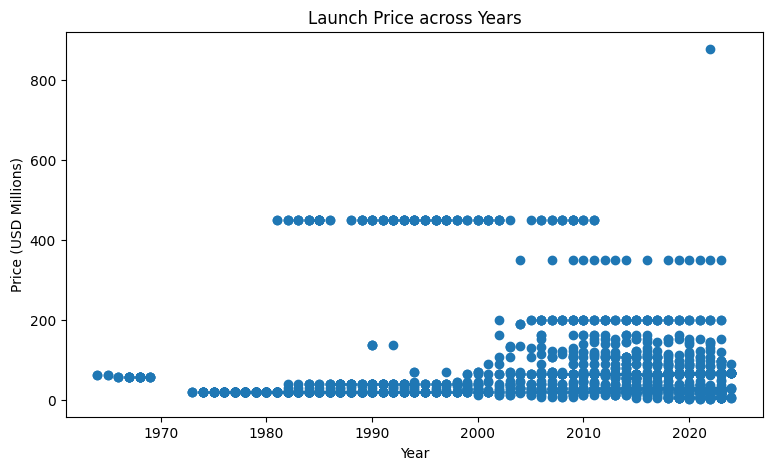

In [10]:
#Algorithm 5: Scatter Plot - Launch Price across Years

sub = df.dropna(subset=['Price', 'Year'])

plt.figure(figsize=(9,5))
plt.scatter(sub['Year'], sub['Price'])

plt.title("Launch Price across Years")
plt.xlabel("Year")
plt.ylabel("Price (USD Millions)")

plt.show()

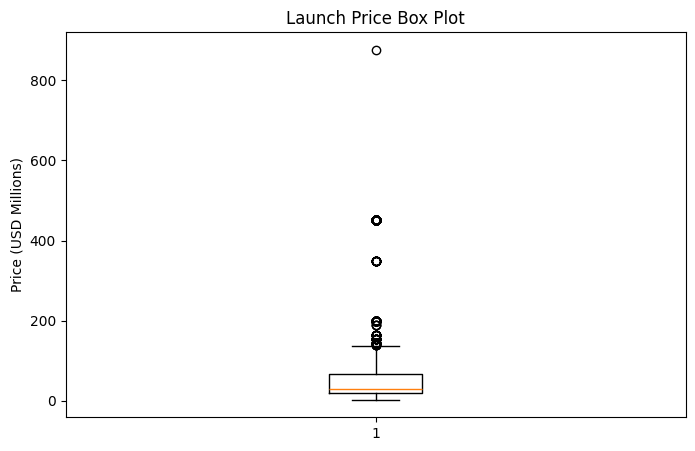

In [11]:
#Algorithm 6: Box Plot - Launch Price Distribution

plt.figure(figsize=(8,5))
plt.boxplot(price)

plt.title("Launch Price Box Plot")
plt.ylabel("Price (USD Millions)")

plt.show()

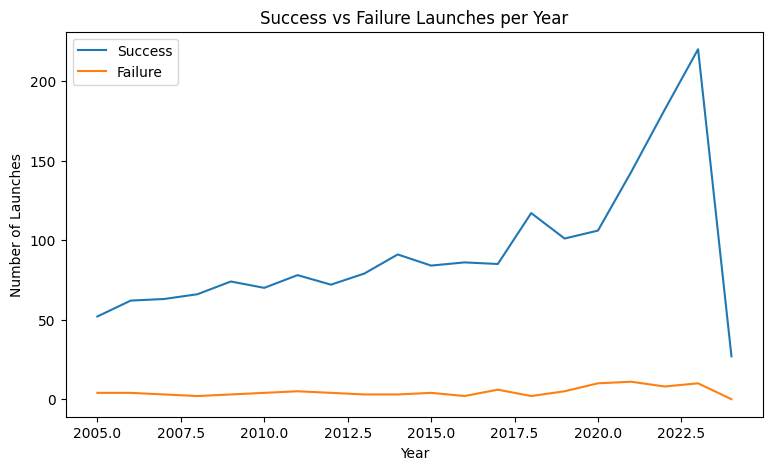

In [12]:
#Algorithm 7: Multiple Line Charts - Success vs Failure Launches per Year

succ = df[df['Mission_Status'] == 'Success'].groupby('Year').size()
fail = df[df['Mission_Status'] == 'Failure'].groupby('Year').size()

years = sorted(set(succ.index) | set(fail.index))
years = [y for y in years if y >= 2005]

succ_vals = [succ.get(y, 0) for y in years]
fail_vals = [fail.get(y, 0) for y in years]

plt.figure(figsize=(9,5))
plt.plot(years, succ_vals, label="Success")
plt.plot(years, fail_vals, label="Failure")

plt.title("Success vs Failure Launches per Year")
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.legend()

plt.show()

In [13]:
#Experiment - 5B

print("Welcome to Data Analytics Lab")
print("Experiment 5B")
print("Data Visualization - All Space Mission Launches")

Welcome to Data Analytics Lab
Experiment 5B
Data Visualization - All Space Mission Launches


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas Version :", pd.__version__)
print("Seaborn Version :", sns.__version__)
print("Libraries Imported Successfully")

Pandas Version : 3.0.2
Seaborn Version : 0.13.2
Libraries Imported Successfully


In [15]:
# Load Space Mission Launches dataset
df = pd.read_csv("all_space_mission_launches.csv")

print("Dataset Preview:")
df.head()

Dataset Preview:


,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,NaN,Success
1,1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,67.0,Success
2,2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,NaN,Success
3,3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,30.8,Success
4,4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,7.5,Success


In [16]:
# Select numerical columns
num_cols = df.select_dtypes(include="number").columns

print("Numerical columns:")
print(num_cols.tolist())

Numerical columns:
['Unnamed: 0', 'Price']


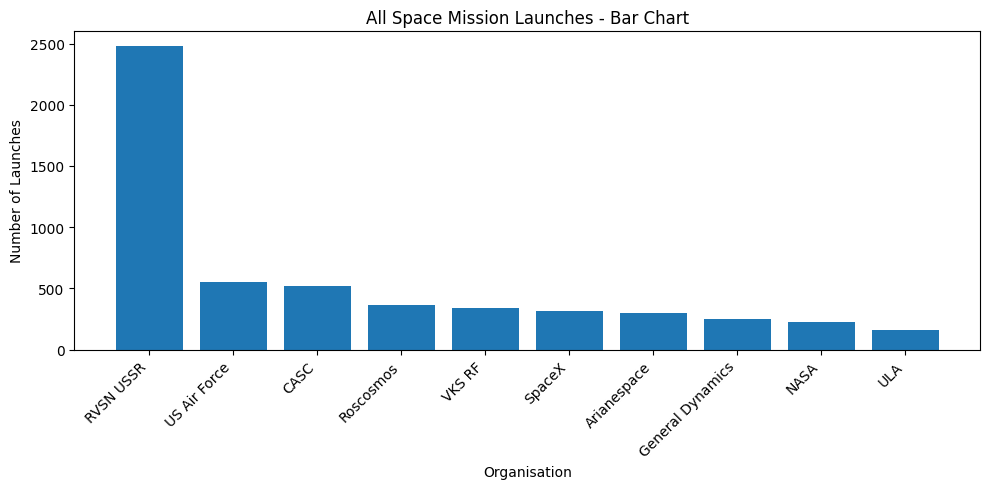

In [17]:
# 1. BAR CHART

top10 = df["Organisation"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10.values)

plt.title("All Space Mission Launches - Bar Chart")
plt.xlabel("Organisation")
plt.ylabel("Number of Launches")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

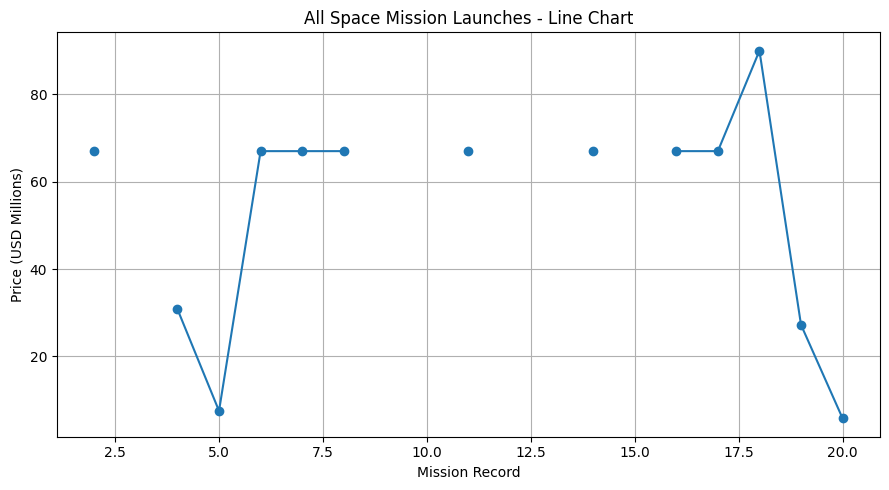

In [18]:
# 2. LINE CHART

first20 = df.head(20)

plt.figure(figsize=(9,5))
plt.plot(range(1, len(first20) + 1), first20["Price"], marker="o")

plt.title("All Space Mission Launches - Line Chart")
plt.xlabel("Mission Record")
plt.ylabel("Price (USD Millions)")
plt.grid()

plt.tight_layout()
plt.show()

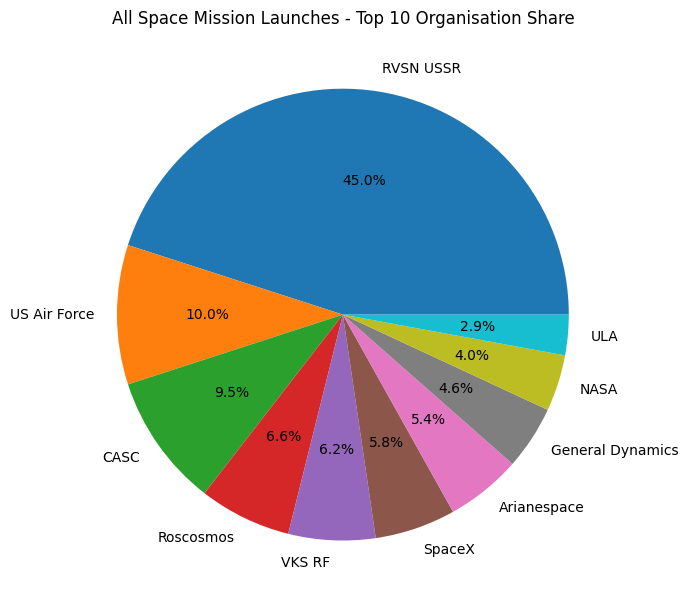

In [19]:
# 3. PIE CHART

plt.figure(figsize=(7,7))
plt.pie(top10.values, labels=top10.index, autopct="%1.1f%%")

plt.title("All Space Mission Launches - Top 10 Organisation Share")

plt.tight_layout()
plt.show()

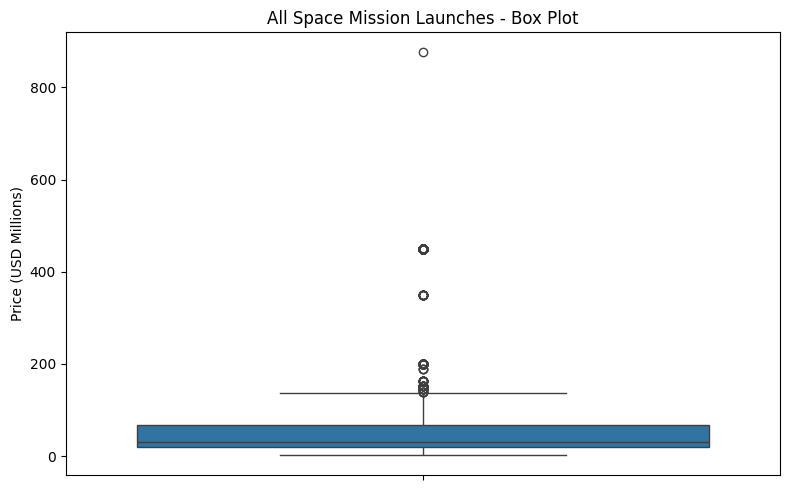

In [20]:
# 4. BOX PLOT

plt.figure(figsize=(8,5))
sns.boxplot(y=df["Price"])

plt.title("All Space Mission Launches - Box Plot")
plt.ylabel("Price (USD Millions)")

plt.tight_layout()
plt.show()

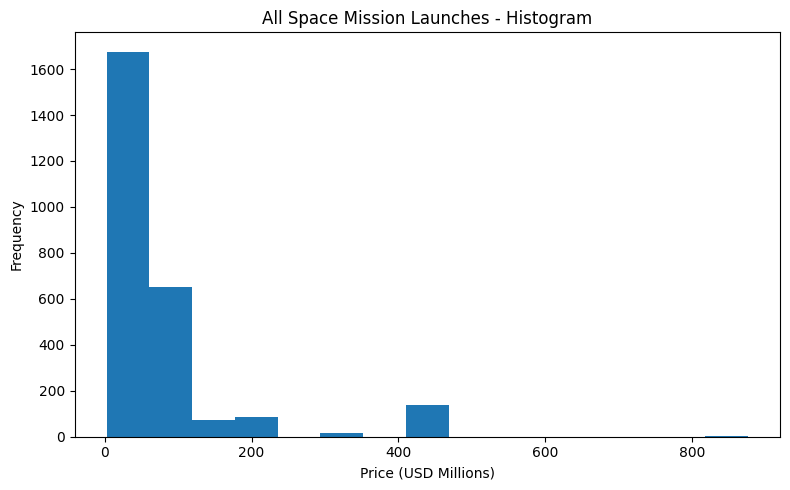

In [21]:
# 5. HISTOGRAM

plt.figure(figsize=(8,5))
plt.hist(df["Price"].dropna(), bins=15)

plt.title("All Space Mission Launches - Histogram")
plt.xlabel("Price (USD Millions)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()